In [214]:
import pandas as pd

df = pd.read_csv('../data/ai4i2020.csv')

df

,UDI,Product ID,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure,TWF,HDF,PWF,OSF,RNF
0,1,M14860,M,298.1,308.6,1551,42.8,0,0,0,0,0,0,0
1,2,L47181,L,298.2,308.7,1408,46.3,3,0,0,0,0,0,0
2,3,L47182,L,298.1,308.5,1498,49.4,5,0,0,0,0,0,0
3,4,L47183,L,298.2,308.6,1433,39.5,7,0,0,0,0,0,0
4,5,L47184,L,298.2,308.7,1408,40.0,9,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9995,9996,M24855,M,298.8,308.4,1604,29.5,14,0,0,0,0,0,0
9996,9997,H39410,H,298.9,308.4,1632,31.8,17,0,0,0,0,0,0
9997,9998,M24857,M,299.0,308.6,1645,33.4,22,0,0,0,0,0,0
9998,9999,H39412,H,299.0,308.7,1408,48.5,25,0,0,0,0,0,0


In [215]:
df['Type'].value_counts()
print(df['Machine failure'].value_counts())

print(df['TWF'].value_counts())
print(df['HDF'].value_counts())
print(df['PWF'].value_counts())
print(df['OSF'].value_counts())
print(df['RNF'].value_counts())

Machine failure
0    9661
1     339
Name: count, dtype: int64
TWF
0    9954
1      46
Name: count, dtype: int64
HDF
0    9885
1     115
Name: count, dtype: int64
PWF
0    9905
1      95
Name: count, dtype: int64
OSF
0    9902
1      98
Name: count, dtype: int64
RNF
0    9981
1      19
Name: count, dtype: int64


In [216]:
info = df.info()
isnull = df.isnull().sum()
Typen = df.dtypes
nunique = df.nunique()

print(info, isnull, Typen, nunique)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   UDI                      10000 non-null  int64  
 1   Product ID               10000 non-null  object 
 2   Type                     10000 non-null  object 
 3   Air temperature [K]      10000 non-null  float64
 4   Process temperature [K]  10000 non-null  float64
 5   Rotational speed [rpm]   10000 non-null  int64  
 6   Torque [Nm]              10000 non-null  float64
 7   Tool wear [min]          10000 non-null  int64  
 8   Machine failure          10000 non-null  int64  
 9   TWF                      10000 non-null  int64  
 10  HDF                      10000 non-null  int64  
 11  PWF                      10000 non-null  int64  
 12  OSF                      10000 non-null  int64  
 13  RNF                      10000 non-null  int64  
dtypes: float64(3), int64(9)

In [217]:
df.drop(columns=['UDI','Product ID'],inplace=True)

In [218]:
import numpy as np
df['temperature_difference']=df['Process temperature [K]']-df['Air temperature [K]']

df['Mechanical Power [W]']=np.round((df['Torque [Nm]']*df['Rotational speed [rpm]']* 2 * np.pi) / 60,4)

df.describe().T

,count,mean,std,min,25%,50%,75%,max
Air temperature [K],10000.0,300.004930,2.000259,295.3000,298.3000,300.10000,301.5000,304.500
Process temperature [K],10000.0,310.005560,1.483734,305.7000,308.8000,310.10000,311.1000,313.800
Rotational speed [rpm],10000.0,1538.776100,179.284096,1168.0000,1423.0000,1503.00000,1612.0000,2886.000
Torque [Nm],10000.0,39.986910,9.968934,3.8000,33.2000,40.10000,46.8000,76.600
Tool wear [min],10000.0,107.951000,63.654147,0.0000,53.0000,108.00000,162.0000,253.000
Machine failure,10000.0,0.033900,0.180981,0.0000,0.0000,0.00000,0.0000,1.000
TWF,10000.0,0.004600,0.067671,0.0000,0.0000,0.00000,0.0000,1.000
HDF,10000.0,0.011500,0.106625,0.0000,0.0000,0.00000,0.0000,1.000
PWF,10000.0,0.009500,0.097009,0.0000,0.0000,0.00000,0.0000,1.000
OSF,10000.0,0.009800,0.098514,0.0000,0.0000,0.00000,0.0000,1.000


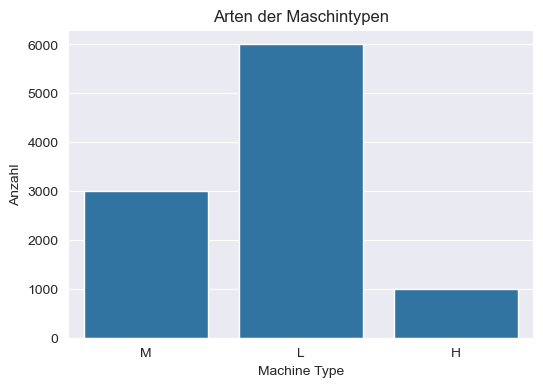

In [219]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(6,4))
sns.countplot(x='Type', data=df)
plt.title('Arten der Maschintypen')
plt.xlabel('Machine Type')
plt.ylabel('Anzahl')
plt.show()

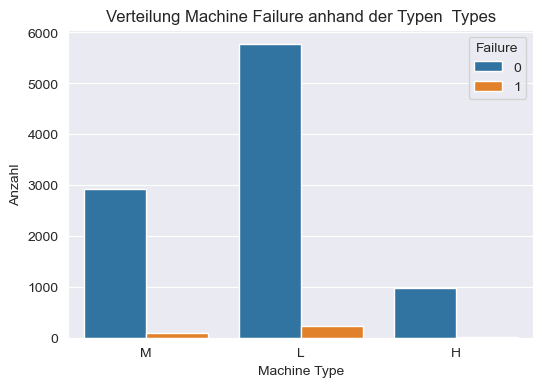

In [220]:
plt.figure(figsize=(6,4))
sns.countplot(x='Type', hue='Machine failure', data=df)
plt.title('Verteilung Machine Failure anhand der Typen  Types')
plt.xlabel('Machine Type')
plt.ylabel('Anzahl')
plt.legend(title='Failure')
plt.show()

<Axes: title={'center': 'Correlation matrix'}>

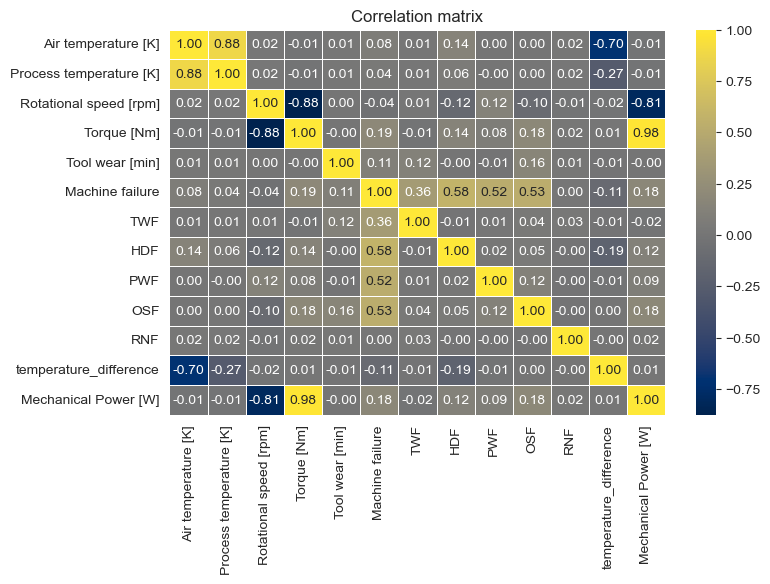

In [221]:
import matplotlib.pyplot as plt
import seaborn as sns

corr_matrix = df.corr(numeric_only=True)
plt.figure(figsize=(8,5))
plt.title('Correlation matrix')
sns.heatmap(corr_matrix,annot=True,cmap='cividis',fmt=".2f", linewidths=0.5)

In [222]:
# Ändern der Bezeichnung der Types in Label (M = 2 / L = 1 / H = 0) 
from sklearn.preprocessing import LabelEncoder

df['Type'] = LabelEncoder().fit_transform(df['Type'])
df['Type'].value_counts()

Type
1    6000
2    2997
0    1003
Name: count, dtype: int64

In [223]:
# Scalen der nummerischen Features
from sklearn.preprocessing import StandardScaler
scale=StandardScaler()
data=pd.DataFrame(scale.fit_transform(df),columns=df.columns,index=df.index)

data.sample(10)

,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure,TWF,HDF,PWF,OSF,RNF,temperature_difference,Mechanical Power [W]
8348,1.333889,-0.652413,-0.273351,-0.484039,0.272168,1.131939,-0.187322,-0.06798,-0.10786,-0.097934,-0.099484,-0.04363,0.898432,0.199484
4071,-0.332223,0.947460,0.400658,-1.158979,2.870369,-0.360576,5.338401,-0.06798,-0.10786,10.210933,-0.099484,-0.04363,-1.299274,3.074731
6737,1.333889,0.847468,0.670261,-0.009907,-0.650745,0.597776,-0.187322,-0.06798,-0.10786,-0.097934,-0.099484,-0.04363,-0.699899,-0.831747
8573,-0.332223,-1.202370,-1.082162,0.486537,-0.761093,0.346405,-0.187322,-0.06798,-0.10786,-0.097934,-0.099484,-0.04363,0.798537,-0.714711
7338,-0.332223,-0.102457,0.333257,-0.238606,-0.119067,1.681813,-0.187322,-0.06798,-0.10786,-0.097934,-0.099484,-0.04363,0.698641,-0.188603
5431,-0.332223,1.397424,1.681275,-0.428259,0.342390,-0.627657,-0.187322,-0.06798,-0.10786,-0.097934,-0.099484,-0.04363,-0.300317,0.341783
7305,1.333889,-0.002465,0.333257,1.401332,-1.433215,0.236430,-0.187322,-0.06798,-0.10786,-0.097934,-0.099484,-0.04363,0.498849,-1.370030
8231,-0.332223,-0.452429,0.333257,-0.668113,0.884100,-0.501972,-0.187322,-0.06798,-0.10786,-0.097934,-0.099484,-0.04363,1.397911,0.910471
4518,-0.332223,1.197440,0.198455,-0.327854,0.583150,0.236430,-0.187322,-0.06798,-0.10786,-0.097934,-0.099484,-0.04363,-2.098440,0.766916
691,-0.332223,-1.152374,-0.610355,0.135121,-0.068909,-0.816186,-0.187322,-0.06798,-0.10786,-0.097934,-0.099484,-0.04363,1.397911,0.143119


In [224]:
# Trennung von Test und Trainingsdaten
# Ausgleich der Ausfälle mit keinen Ausfällen mittels SMOTE von imblearn.over_sampling 
from sklearn.model_selection import train_test_split
from imblearn.over_sampling import SMOTE

#Art der Ausfälle werden entfernt. Wir wollen erst einmal wissen wann ein Machine failure passiert
df.drop(columns=['TWF','HDF','PWF','OSF','RNF'],inplace=True)

X = df
y = df.pop("Machine failure")

smote = SMOTE(random_state=42)
X_resampled, y_resampled = smote.fit_resample(X, y)

#X_train,X_test,Y_train,Y_test=train_test_split(X,y,test_size=0.3, random_state=0)
X_train,X_test,Y_train,Y_test=train_test_split(X_resampled,y_resampled,test_size=0.3, random_state=0)

In [225]:
# Mehrere Verschiedene Modelle werden anhand deren Accuracy bewertet 
from sklearn.metrics import accuracy_score
from sklearn.linear_model import LogisticRegression,LogisticRegressionCV,SGDClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier,AdaBoostClassifier,BaggingClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier

models = {
    'Logistic Regression': LogisticRegression(),
        'Logistic Regression CV': LogisticRegressionCV(),
    'SGD': SGDClassifier(),
    
    'Random Forest': RandomForestClassifier(),
    'Gradient Boosting': GradientBoostingClassifier(),
    'AdaBoost': AdaBoostClassifier(),
    'Bagging': BaggingClassifier(),
    'Decision Tree': DecisionTreeClassifier(),
    'Support Vector Machine': SVC(),
    'K-Nearest Neighbors': KNeighborsClassifier()
}

def evaluate_model(X_train,X_test,Y_train,Y_test):
    result=[]
    for name, model in models.items():
        model.fit(X_train,Y_train)
        y_pred=model.predict(X_test)
        acc=accuracy_score(Y_test,y_pred)
        result.append((name,acc))
    
    result.sort(key=lambda x: x[1], reverse=True)
    return result

results = evaluate_model(X_train,X_test,Y_train,Y_test)
    
print("Model Performance:")
for name, acc in results:
    print(f"{name}: {acc:.6f}")
    
#Fehlermedlung kann ignoriert werden

C:\Users\Moritz\anaconda3\envs\WPI2\Lib\site-packages\sklearn\linear_model\_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=100).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
C:\Users\Moritz\anaconda3\envs\WPI2\Lib\site-packages\sklearn\linear_model\_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=100).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessi

Model Performance:
Random Forest: 0.977575
Bagging: 0.972745
Decision Tree: 0.968087
Gradient Boosting: 0.955322
K-Nearest Neighbors: 0.930999
AdaBoost: 0.917371
Logistic Regression CV: 0.859583
Logistic Regression: 0.853545
Support Vector Machine: 0.790754
SGD: 0.638434


In [226]:
# Man sieht mehrere Modelle könnten verwendet werden da sie alle eine recht gute Accuracy besitzen
# Random Forrest als weiterbearbeitung verwendet 
#in der Klammer (n = Anzahl von Bäumen, Wie tief ist ein einzelner Baum, Wie werden diese Gewertet, Random Faktor) 
RF = RandomForestClassifier(n_estimators=15, max_depth=6, class_weight = 'balanced', random_state =0)

RF.fit(X_train,Y_train)
y_pred=RF.predict(X_test)
acc=accuracy_score(Y_test,y_pred)
#Accuracy des trainierten Models mit den Test Daten
acc

0.934448852854925

--------- Random Forest Classification Report ------ 


              precision    recall  f1-score   support

           0       0.93      0.94      0.93      2902
           1       0.94      0.93      0.93      2895

    accuracy                           0.93      5797
   macro avg       0.93      0.93      0.93      5797
weighted avg       0.93      0.93      0.93      5797



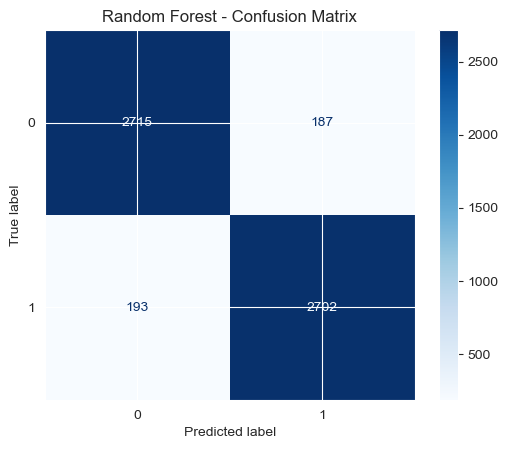

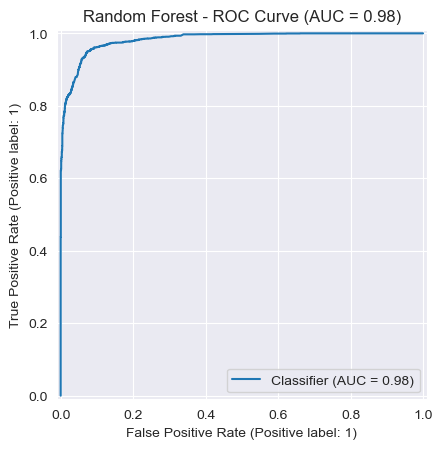

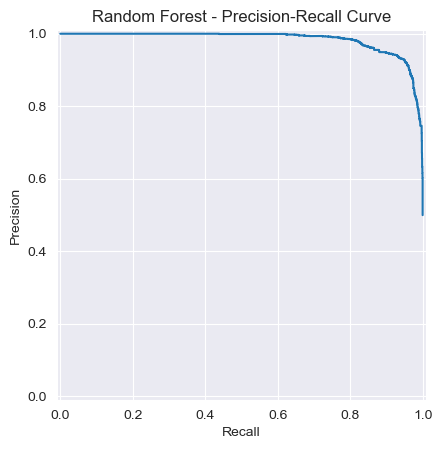

In [227]:
# Genauere Auswertung des Random Forests
from sklearn.metrics import (
    classification_report, 
    confusion_matrix, 
    ConfusionMatrixDisplay, 
    roc_auc_score, 
    RocCurveDisplay, 
    precision_recall_curve, 
    PrecisionRecallDisplay
)

def evaluate_model(model, X_test, y_test, model_name="Model"):
    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:, 1]

    
    print(f"--------- {model_name} Classification Report ------ \n\n")
    print(classification_report(y_test, y_pred))

    # Confusion Matrix
    cm = confusion_matrix(y_test, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm)
    disp.plot(cmap='Blues')
    plt.title(f"{model_name} - Confusion Matrix")
    plt.show()

    # ROC Curve
    roc_auc = roc_auc_score(y_test, y_prob)
    RocCurveDisplay.from_predictions(y_test, y_prob)
    plt.title(f"{model_name} - ROC Curve (AUC = {roc_auc:.2f})")
    plt.show()

    # Precision-Recall Curve
    precision, recall, _ = precision_recall_curve(y_test, y_prob)
    PrecisionRecallDisplay(precision=precision, recall=recall).plot()
    plt.title(f"{model_name} - Precision-Recall Curve")
    plt.show()
    
evaluate_model(RF, X_test, Y_test, model_name="Random Forest")

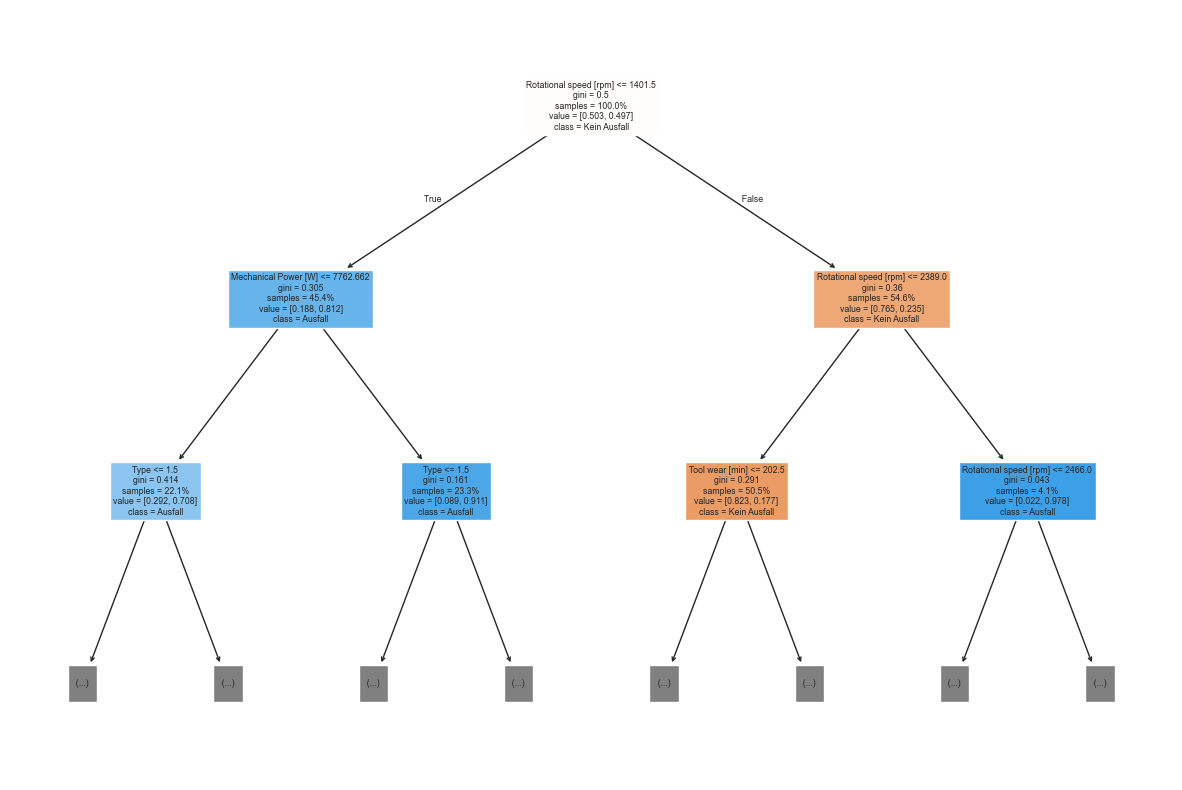

In [228]:
from sklearn import tree
import matplotlib.pyplot as plt

class_names = ["Kein Ausfall", "Ausfall"]

#Bei tree.plot_tree(RF.estimators_[1] kann in die [] eine Zahl von 0 bis 14 eingegeben werden und zeigt die einzelnen unterschiedlichen Entscheidungsbäume
plt.figure(figsize=(15, 10))
tree.plot_tree(RF.estimators_[1],
feature_names=X_train.columns,
class_names=class_names,
filled=True,
max_depth=2,
proportion=True)
plt.show()

C:\Users\Moritz\AppData\Local\Temp\ipykernel_29620\4187035505.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance', y='Feature', data=feature_imp_df, palette='viridis')


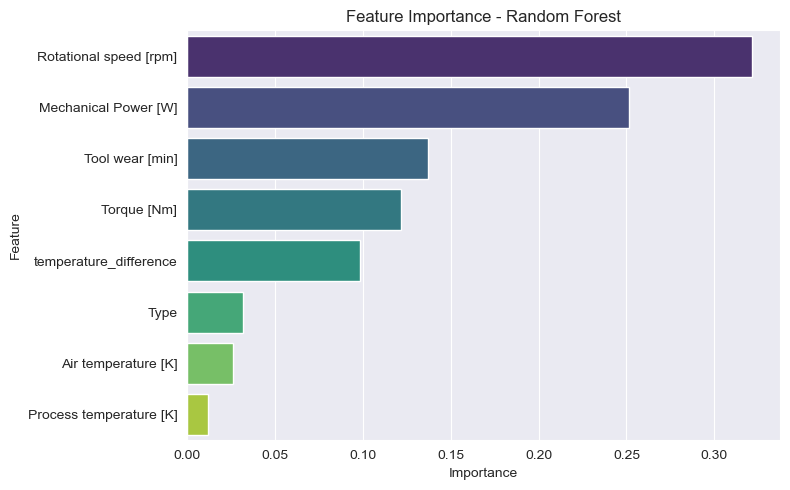

In [229]:
importances = RF.feature_importances_
feature_names = X.columns

# DataFrame erzeugt
feature_imp_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importances
}).sort_values(by='Importance', ascending=False)

plt.figure(figsize=(8, 5))
sns.barplot(x='Importance', y='Feature', data=feature_imp_df, palette='viridis')
plt.title('Feature Importance - Random Forest')
plt.tight_layout()
plt.show()